## **Configure Kaggle & Download Dataset**

In [8]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets download -d dhoogla/unswnb15
import zipfile
with zipfile.ZipFile("unswnb15.zip", 'r') as zip_ref:
    zip_ref.extractall("unsw_nb15")


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/dhoogla/unswnb15
License(s): CC-BY-NC-SA-4.0
unswnb15.zip: Skipping, found more recently modified local copy (use --force to force download)


# **Read & Concatenate Train/Test Data**

In [23]:
import pandas as pd

train_df = pd.read_parquet("/content/unsw_nb15/UNSW_NB15_training-set.parquet")
test_df = pd.read_parquet("/content/unsw_nb15/UNSW_NB15_testing-set.parquet")
df = pd.concat([train_df, test_df], ignore_index=True)
df.head()


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                257673 non-null  float32 
 1   proto              257673 non-null  object  
 2   service            257673 non-null  category
 3   state              257673 non-null  object  
 4   spkts              257673 non-null  int16   
 5   dpkts              257673 non-null  int16   
 6   sbytes             257673 non-null  int32   
 7   dbytes             257673 non-null  int32   
 8   rate               257673 non-null  float32 
 9   sload              257673 non-null  float32 
 10  dload              257673 non-null  float32 
 11  sloss              257673 non-null  int16   
 12  dloss              257673 non-null  int16   
 13  sinpkt             257673 non-null  float32 
 14  dinpkt             257673 non-null  float32 
 15  sjit               257673 non-null

 # **Preprocess the Dataset**

In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Make a copy
df_clean = df.copy()



# Encode object and categorical columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Separate features and target
X = df_clean.drop(columns=['label'])
y = df_clean['label']


# **Exploratry data Analysis**

## **Visualize Label Distribution**

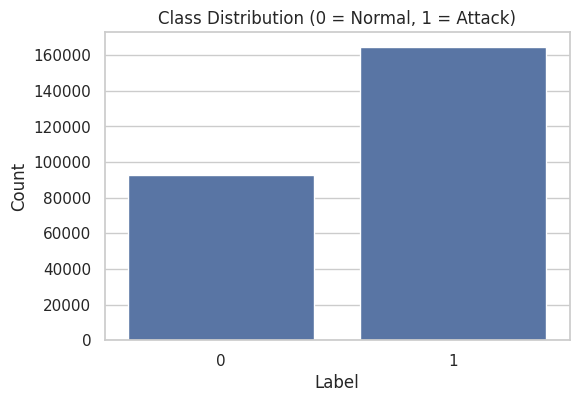

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Class Distribution (0 = Normal, 1 = Attack)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


# **Count plot to show protocol by attack Category**

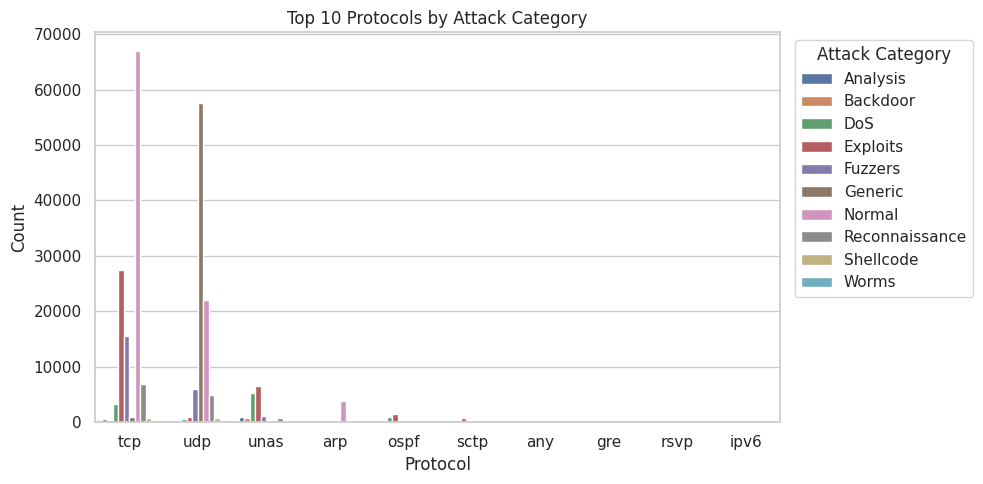

In [13]:

# Identify top 10 most common protocols
top_protos = df['proto'].value_counts().nlargest(10).index

# Filter dataset to top protocols only
filtered_df = df[df['proto'].isin(top_protos)]

# Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_df, x='proto', hue='attack_cat', order=top_protos)
plt.title("Top 10 Protocols by Attack Category")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Attack Category')
plt.tight_layout()
plt.show()

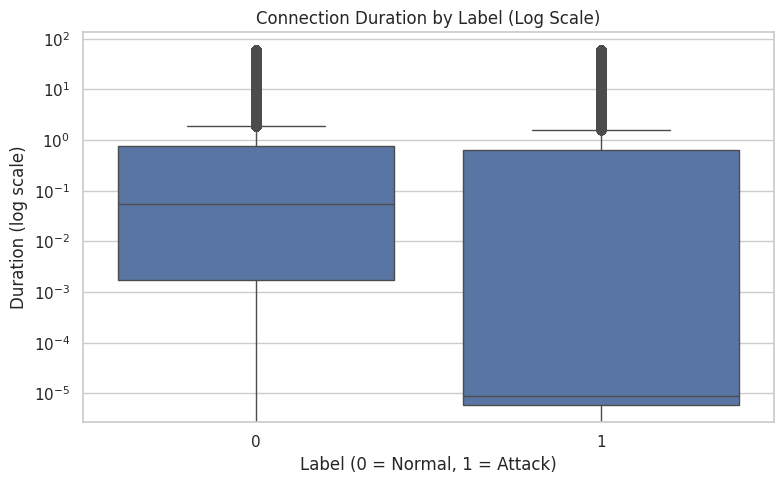

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='dur')
plt.yscale("log")
plt.title("Connection Duration by Label (Log Scale)")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Duration (log scale)")
plt.tight_layout()
plt.show()

# **Split the Data Set**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)


📊 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18613
           1       1.00      1.00      1.00     32922

    accuracy                           1.00     51535
   macro avg       1.00      1.00      1.00     51535
weighted avg       1.00      1.00      1.00     51535



<Figure size 600x400 with 0 Axes>

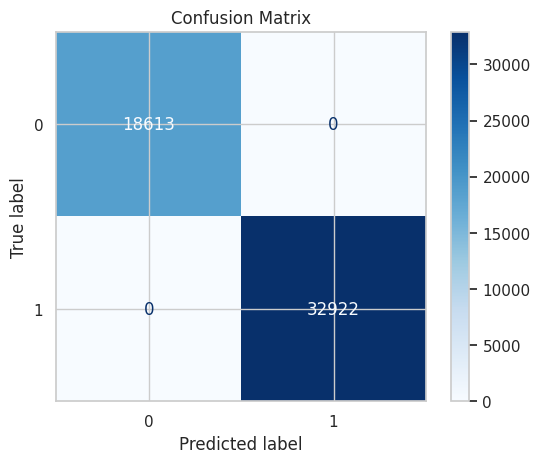

In [17]:
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
